## Objective

The objective of this task is to build a supervised machine learning model to predict loan approval status based on borrower and loan-related features. The analysis focuses on data preprocessing, missing value handling, categorical encoding, feature scaling, class imbalance handling, model comparison, evaluation using precision, recall, F1-score and ROC-AUC, and business-oriented interpretation of model results.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "/content/drive/MyDrive/InternSpark Data Science Internship/Datasets/Loan-Approval-Dataset/loan_approval_dataset.csv"

df = pd.read_csv(dataset_path)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (614, 13)

Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [9]:
# Clean column names
df.columns = df.columns.str.strip()

print("Columns after cleaning:")
print(df.columns.tolist())

df.head()

Columns after cleaning:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [10]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["Loan_Status"].value_counts())

Dataset Shape: (614, 13)

Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Target Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [11]:
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


In [13]:
# Fill categorical missing values with mode
categorical_missing_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History",
    "Loan_Amount_Term"
]

for col in categorical_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values with median
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [14]:
# Create total income feature
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

# Log transformation to reduce skewness
df["LoanAmount_Log"] = np.log1p(df["LoanAmount"])
df["Total_Income_Log"] = np.log1p(df["Total_Income"])

df[["ApplicantIncome", "CoapplicantIncome", "Total_Income", "LoanAmount", "LoanAmount_Log", "Total_Income_Log"]].head()

,ApplicantIncome,CoapplicantIncome,Total_Income,LoanAmount,LoanAmount_Log,Total_Income_Log
0,5849,0.0,5849.0,128.0,4.859812,8.674197
1,4583,1508.0,6091.0,128.0,4.859812,8.714732
2,3000,0.0,3000.0,66.0,4.204693,8.006701
3,2583,2358.0,4941.0,120.0,4.795791,8.505525
4,6000,0.0,6000.0,141.0,4.955827,8.699681


In [15]:
# Drop Loan_ID because it is only an identifier
X = df.drop(["Loan_ID", "Loan_Status"], axis=1)

# Convert target column: Y = 1, N = 0
y = df["Loan_Status"].map({"Y": 1, "N": 0})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution after encoding:")
print(y.value_counts())

Feature shape: (614, 14)
Target shape: (614,)

Target distribution after encoding:
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [16]:
# Convert categorical variables into numerical dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (614, 17)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income,LoanAmount_Log,Total_Income_Log,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,5849.0,4.859812,8.674197,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,6091.0,4.859812,8.714732,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,3000.0,4.204693,8.006701,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,4941.0,4.795791,8.505525,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,6000.0,4.955827,8.699681,True,False,False,False,False,False,False,False,True


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())

X_train shape: (491, 17)
X_test shape: (123, 17)
y_train distribution:
Loan_Status
1    337
0    154
Name: count, dtype: int64

y_test distribution:
Loan_Status
1    85
0    38
Name: count, dtype: int64


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed.
X_train_scaled shape: (491, 17)
X_test_scaled shape: (123, 17)


Class Distribution Percentage:
Loan_Status
1    68.729642
0    31.270358
Name: proportion, dtype: float64


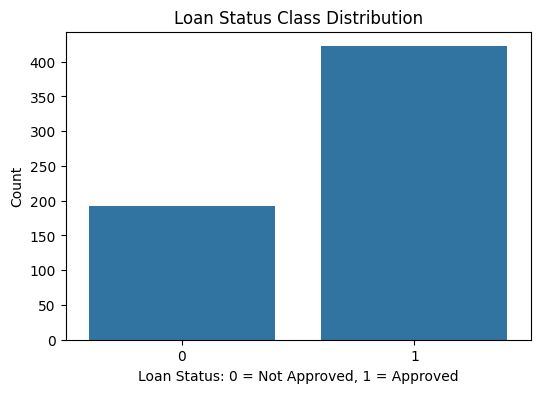

In [19]:
class_distribution = y.value_counts(normalize=True) * 100

print("Class Distribution Percentage:")
print(class_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Loan Status Class Distribution")
plt.xlabel("Loan Status: 0 = Not Approved, 1 = Approved")
plt.ylabel("Count")
plt.show()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [24]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42)
}

model_results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    model_results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8293,0.8721,0.8824,0.8772,0.8632
1,Decision Tree,0.7642,0.8590,0.7882,0.8221,0.7494
2,Random Forest,0.8699,0.8710,0.9529,0.9101,0.8550


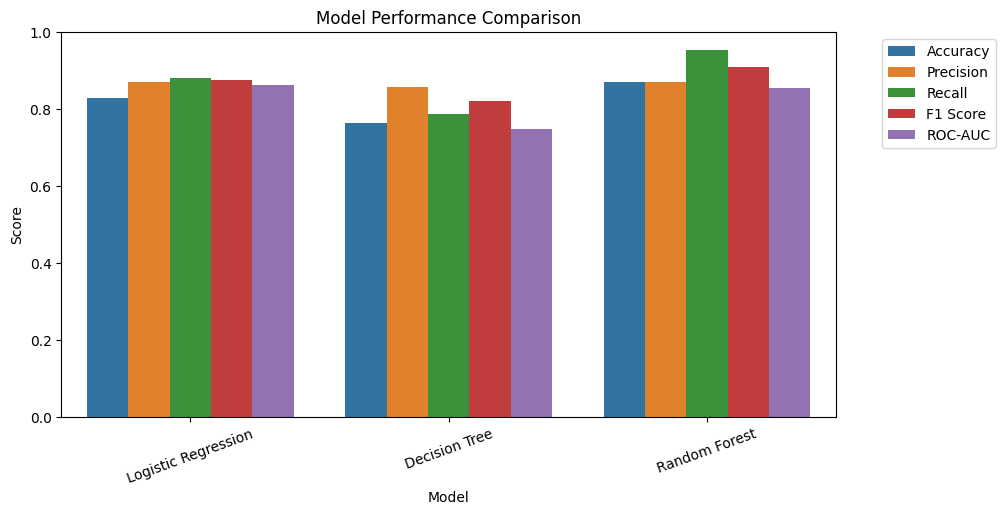

In [25]:
plt.figure(figsize=(10, 5))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [26]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model based on F1 Score:", best_model_name)

Best Model based on F1 Score: Random Forest


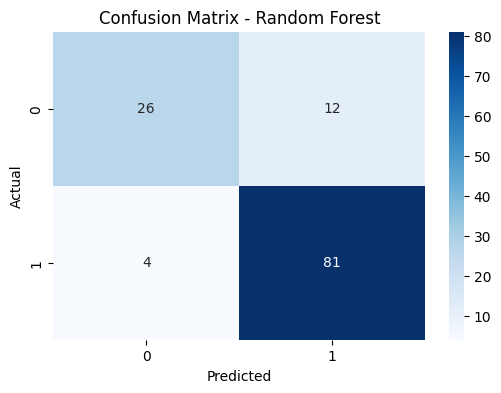

              precision    recall  f1-score   support

           0       0.87      0.68      0.76        38
           1       0.87      0.95      0.91        85

    accuracy                           0.87       123
   macro avg       0.87      0.82      0.84       123
weighted avg       0.87      0.87      0.87       123



In [27]:
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred_best))

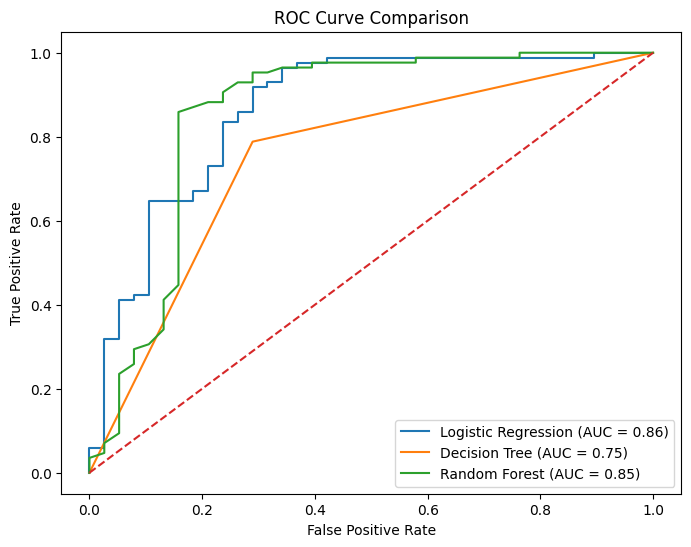

In [28]:
plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [29]:
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

thresholds_to_test = [0.3, 0.4, 0.45, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_proba_best >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": round(precision_score(y_test, y_pred_threshold), 4),
        "Recall": round(recall_score(y_test, y_pred_threshold), 4),
        "F1 Score": round(f1_score(y_test, y_pred_threshold), 4)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.8058,0.9765,0.8830
1,0.40,0.8300,0.9765,0.8973
2,0.45,0.8454,0.9647,0.9011
3,0.50,0.8710,0.9529,0.9101
4,0.60,0.8953,0.9059,0.9006
5,0.70,0.9130,0.7412,0.8182


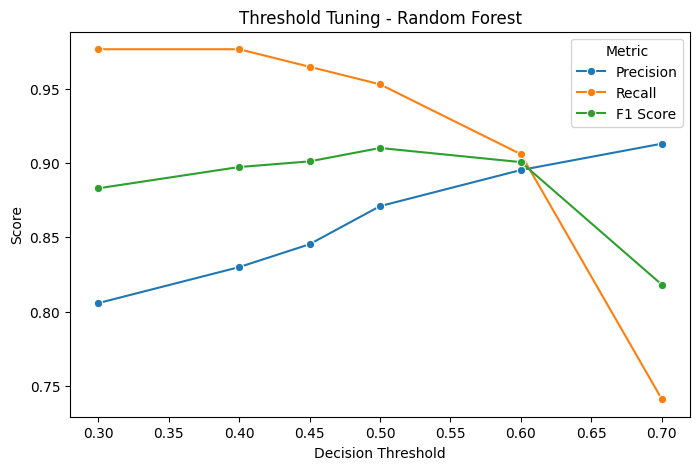

In [30]:
threshold_melted = threshold_df.melt(id_vars="Threshold", var_name="Metric", value_name="Score")

plt.figure(figsize=(8, 5))
sns.lineplot(data=threshold_melted, x="Threshold", y="Score", hue="Metric", marker="o")
plt.title(f"Threshold Tuning - {best_model_name}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.show()

In [31]:
print("BUSINESS INTERPRETATION")
print("-" * 60)
print(f"The best performing model based on F1 Score is: {best_model_name}")
print("For loan approval prediction, precision and recall must be balanced carefully.")
print("Higher precision reduces the risk of approving applicants who may default.")
print("Higher recall helps identify more eligible applicants who should be approved.")
print("A threshold around 0.45 to 0.50 can be considered depending on the business goal.")
print("If the company wants safer approvals, use a higher threshold.")
print("If the company wants to approve more eligible customers, use a slightly lower threshold.")
print("The model should support human decision-making and should not fully replace manual loan review.")

BUSINESS INTERPRETATION
------------------------------------------------------------
The best performing model based on F1 Score is: Random Forest
For loan approval prediction, precision and recall must be balanced carefully.
Higher precision reduces the risk of approving applicants who may default.
Higher recall helps identify more eligible applicants who should be approved.
A threshold around 0.45 to 0.50 can be considered depending on the business goal.
If the company wants safer approvals, use a higher threshold.
If the company wants to approve more eligible customers, use a slightly lower threshold.
The model should support human decision-making and should not fully replace manual loan review.


In [34]:
threshold_df


,Threshold,Precision,Recall,F1 Score
0,0.30,0.8058,0.9765,0.8830
1,0.40,0.8300,0.9765,0.8973
2,0.45,0.8454,0.9647,0.9011
3,0.50,0.8710,0.9529,0.9101
4,0.60,0.8953,0.9059,0.9006
5,0.70,0.9130,0.7412,0.8182


In [35]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8293,0.8721,0.8824,0.8772,0.8632
1,Decision Tree,0.7642,0.8590,0.7882,0.8221,0.7494
2,Random Forest,0.8699,0.8710,0.9529,0.9101,0.8550


In [36]:
best_model_name

'Random Forest'

Random Forest was selected as the best model based on F1-score. It achieved the highest accuracy of 0.8699, highest recall of 0.9529, and highest F1-score of 0.9101. Although Logistic Regression had a slightly higher ROC-AUC score of 0.8632, Random Forest provided a better balance between precision and recall, making it more suitable for loan approval prediction.

The default threshold of 0.50 is recommended as the initial deployment threshold because it achieved the best F1-score of 0.9101, with precision of 0.8710 and recall of 0.9529. This gives a strong balance between approving eligible applicants and controlling risky approvals.

If the business wants a more conservative approval strategy, a threshold of 0.60 can be considered because it increases precision to 0.8953, but recall decreases to 0.9059.

## Final Model Interpretation

Three supervised machine learning models were compared for loan approval prediction: Logistic Regression, Decision Tree, and Random Forest.

Random Forest performed the best based on F1-score. It achieved an accuracy of 0.8699, precision of 0.8710, recall of 0.9529, F1-score of 0.9101, and ROC-AUC of 0.8550.

Logistic Regression achieved the highest ROC-AUC score of 0.8632, but Random Forest provided better recall and F1-score. Since loan approval prediction requires balancing approval opportunities with risk control, Random Forest was selected as the final model.

## Threshold Recommendation

The default threshold of 0.50 is recommended for initial deployment because it achieved the best F1-score of 0.9101. This threshold provides a strong balance between precision and recall.

If the business wants safer approvals with fewer risky applicants, a threshold of 0.60 can be used because it improves precision to 0.8953. However, this slightly reduces recall, meaning some eligible applicants may be rejected.

## Business Interpretation

The model should be used as a decision-support tool, not as a complete replacement for manual loan review. A lower threshold can approve more applicants but may increase financial risk, while a higher threshold can reduce risk but may reject some eligible customers. Based on the current results, Random Forest with a threshold of 0.50 is recommended as the initial model setup.